#  Student CGPA Prediction — XGBoost Regressor

**Dataset:** `student_dropout_dataset_v3.csv`  
**Task:** Regression — Prediksi nilai **CGPA**  
**Model:** XGBoost Regressor

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import xgboost as xgb

print('Libraries loaded ')
print('XGBoost version:', xgb.__version__)

Libraries loaded 
XGBoost version: 3.2.0


---
## 1.  Cara Melihat Tipe Data

In [2]:
df = pd.read_csv('../student_dropout_dataset_v3.csv')
print('Shape:', df.shape)
df.info()

Shape: (10000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-nul

In [3]:
print('Statistik CGPA:')
print(df['CGPA'].describe())
print('\nMissing Values:', df.isnull().sum().sum())

Statistik CGPA:
count    10000.000000
mean         2.298761
std          1.072555
min          0.000000
25%          1.520000
50%          2.350000
75%          3.150000
max          4.000000
Name: CGPA, dtype: float64

Missing Values: 2011


---
## 2.  Dataset Bisa Digunakan Untuk Apa

| Tujuan | Target | Jenis |
|--------|--------|-------|
| Prediksi Dropout | `Dropout` | Classification |
| **Prediksi CGPA** ← (ini) | `CGPA` | **Regression** |
| Identifikasi fitur paling penting untuk performa akademik | - | Feature Importance |
| Early intervention saat CGPA diprediksi rendah | `CGPA` < threshold | Flagging |

---
## 3.  Kenapa XGBoost Regressor?

XGBoostRegressor mengoptimalkan fungsi loss regresi (MSE default) secara gradient boosting:

```
Ŷ_final = sum(η × h_t(x))   di mana h_t adalah pohon ke-t
```

**Keunggulan dibanding Random Forest untuk Regresi:**
- Biasanya lebih akurat
- Regularisasi L1/L2 built-in
- Early stopping tersedia
- Lebih cepat jika `tree_method='hist'`
- Menangani missing values otomatis

**Cocok digunakan saat:**
- Ingin performa maksimal untuk tabular data
- Dataset berukuran sedang–besar
- Kompetisi machine learning

In [4]:
# Preprocessing
target_col = 'CGPA'
drop_cols = ['Student_ID', 'Dropout', 'GPA', 'Semester_GPA']

df_proc = df.drop(columns=drop_cols).copy()
le = LabelEncoder()
for col in df_proc.select_dtypes(include='object').columns:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

X = df_proc.drop(columns=[target_col])
y = df_proc[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (8000, 14), Test: (2000, 14)


---
## 4.  Parameter Yang Bisa Diubah / Disetel

### XGBRegressor — Parameter Utama:

| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `n_estimators` | 100 | Jumlah boosting rounds |
| `learning_rate` / `eta` | 0.3 | Kecepatan belajar (lebih kecil = lebih akurat, butuh lebih banyak pohon) |
| `max_depth` | 6 | Kedalaman max pohon |
| `subsample` | 1.0 | Proporsi sampel per tree |
| `colsample_bytree` | 1.0 | Proporsi fitur per tree |
| `min_child_weight` | 1 | Sum hessian minimum di leaf |
| `gamma` | 0 | Min gain untuk partisi |
| `reg_alpha` | 0 | L1 regularization |
| `reg_lambda` | 1 | L2 regularization |
| `objective` | `'reg:squarederror'` | Fungsi loss (MSE untuk regresi) |
| `tree_method` | `'auto'` | `'hist'` lebih cepat untuk data besar |

In [5]:
# Build XGBoost Regressor
model = XGBRegressor(
    n_estimators=500,              # Banyak pohon, tapi pakai early stopping
    learning_rate=0.05,            # Learning rate kecil → lebih akurat
    max_depth=5,                   # Kedalaman pohon
    subsample=0.8,                 # 80% sampel per pohon
    colsample_bytree=0.8,          # 80% fitur per pohon
    min_child_weight=5,            # Regularisasi
    gamma=1,                       # Min gain untuk split
    reg_alpha=0.1,                 # L1 reg
    reg_lambda=1.0,                # L2 reg
    objective='reg:squarederror',  # MSE loss
    eval_metric='rmse',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f'XGBoost Regressor berhasil ditraining ')
print(f'Best iteration: {model.best_iteration}')
y_pred = model.predict(X_test)

XGBoost Regressor berhasil ditraining 
Best iteration: 22


---
## 5.  Evaluasi Yang Dipakai

In [6]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

print('=' * 55)
print(' EVALUASI XGBOOST REGRESSOR (CGPA)')
print('=' * 55)
print(f'MAE  : {mae:.4f}')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')
print(f'MAPE : {mape:.2f}%')

 EVALUASI XGBOOST REGRESSOR (CGPA)
MAE  : 0.8591
MSE  : 1.0773
RMSE : 1.0379
R²   : 0.0797
MAPE : 267074941.71%


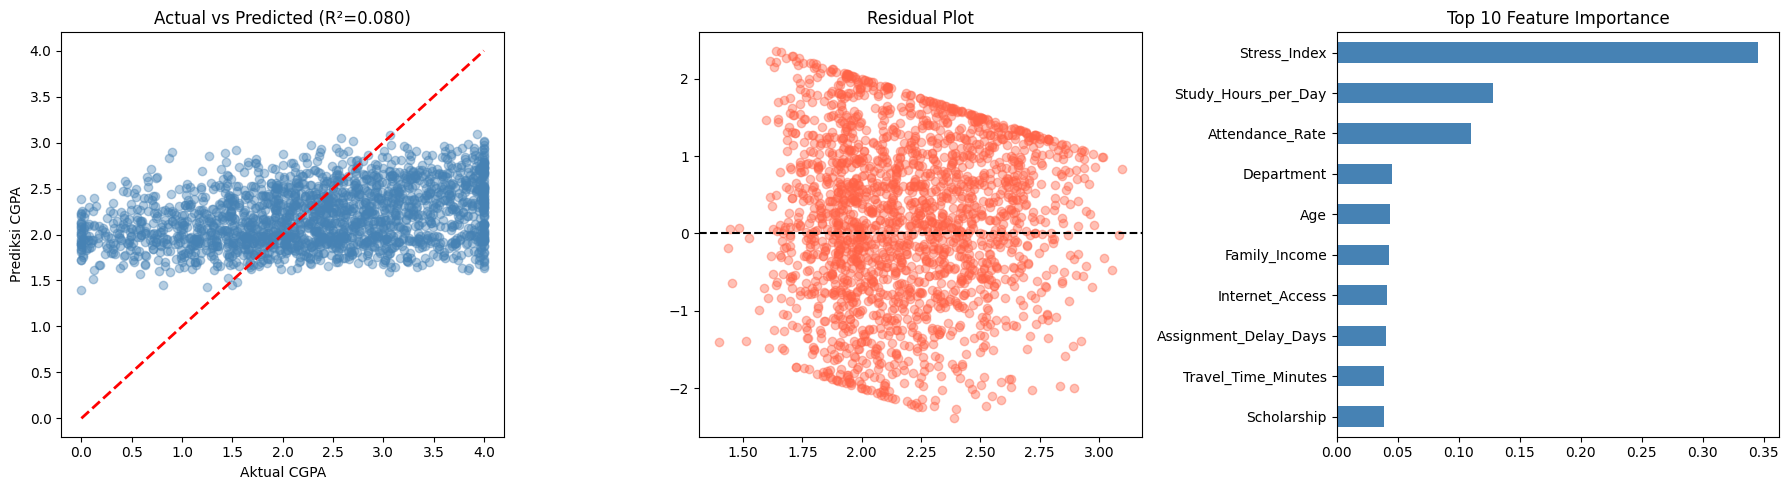

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue')
min_v, max_v = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2)
axes[0].set_xlabel('Aktual CGPA')
axes[0].set_ylabel('Prediksi CGPA')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')

# Residual
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='tomato')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Residual Plot')

# Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
feat_imp.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Top 10 Feature Importance')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

### Konteks CGPA (skala 0.0–4.0):

| Metrik | Sangat Baik | Baik | Cukup | Buruk |
|--------|------------|------|-------|-------|
| MAE | < 0.1 | 0.1–0.2 | 0.2–0.4 | > 0.4 |
| RMSE | < 0.15 | 0.15–0.3 | 0.3–0.5 | > 0.5 |
| R² | > 0.90 | 0.80–0.90 | 0.60–0.80 | < 0.60 |
| MAPE | < 5% | 5–10% | 10–20% | > 20% |

###  Data Leakage:
Jika R² ≈ 1.0, periksa:
- Apakah ada fitur yang 'membocorkan' target? (contoh: `GPA` sangat berkorelasi dengan `CGPA`)
- Apakah kolom correlated sudah di-drop?

### Early Stopping:
- Jika `best_iteration` << `n_estimators` → Model konvergen cepat, kurangi `n_estimators`
- Loss validation terus turun → Bisa naikkan `n_estimators`

In [8]:
r2_train = r2_score(y_train, model.predict(X_train))
print(f'Train R²: {r2_train:.4f}')
print(f'Test R² : {r2:.4f}')

if r2_train - r2 > 0.1:
    print('  Overfitting! Tambah regularisasi (reg_alpha, reg_lambda, gamma)')
elif r2 < 0.6:
    print('  Performa kurang. Coba feature engineering lebih lanjut')
else:
    print('  Model terlihat baik!')

Train R²: 0.2139
Test R² : 0.0797
  Overfitting! Tambah regularisasi (reg_alpha, reg_lambda, gamma)


---
## 7.  Cara Mengoptimasi Model

### Strategi untuk XGBoost Regressor:

1. **Overfitting** → Naikkan `reg_alpha`, `reg_lambda`, `gamma`. Turunkan `max_depth`, `learning_rate`. Tambah `subsample < 1.0`
2. **Underfitting** → Naikkan `n_estimators`, turunkan regularisasi, naikkan `max_depth`
3. **Akurasi belum memuaskan** → Lakukan hyperparameter search lebih comprehensive

### Optuna (Bayesian Optimization) — lebih efisien dari GridSearchCV:
```python
# !pip install optuna
import optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('lr', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
    }
    ...
```

In [9]:
# RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.5, 1]
}

rs = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0),
    param_dist, n_iter=15, cv=5, scoring='r2',
    random_state=42, n_jobs=-1
)
rs.fit(X_train, y_train)
best_model = rs.best_estimator_
y_best = best_model.predict(X_test)

print(f'Best params: {rs.best_params_}')
print(f'Test R²  : {r2_score(y_test, y_best):.4f}')
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_test, y_best)):.4f}')

Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 1, 'colsample_bytree': 0.9}
Test R²  : 0.0431
Test RMSE: 1.0583


---
## 8.  Cara Menyimpan Model

In [10]:
os.makedirs('saved_models', exist_ok=True)

# Simpan dengan joblib
joblib.dump(best_model, 'saved_models/xgb_regressor_cgpa.pkl')
joblib.dump(list(X.columns), 'saved_models/feature_columns_xgb_reg.pkl')
print(' XGBoost Regressor tersimpan!')

# Alternatif: format native XGBoost
best_model.save_model('saved_models/xgb_regressor_cgpa.json')
print(' Juga tersimpan dalam format JSON')

 XGBoost Regressor tersimpan!
 Juga tersimpan dalam format JSON


---
## 9.  Cara Menggunakan Model Hasil Training

In [11]:
loaded_model = joblib.load('saved_models/xgb_regressor_cgpa.pkl')
loaded_cols = joblib.load('saved_models/feature_columns_xgb_reg.pkl')

print('Model dimuat ')

# Prediksi mahasiswa baru
new_students = pd.DataFrame([
    # 3 mahasiswa dengan profil berbeda
    {'Age': 19, 'Gender': 1, 'Family_Income': 50000, 'Internet_Access': 1,
     'Study_Hours_per_Day': 7.0, 'Attendance_Rate': 95, 'Assignment_Delay_Days': 0,
     'Travel_Time_Minutes': 10, 'Part_Time_Job': 0, 'Scholarship': 1,
     'Stress_Index': 3, 'Semester': 2, 'Department': 0, 'Parental_Education': 3},
    {'Age': 22, 'Gender': 0, 'Family_Income': 15000, 'Internet_Access': 0,
     'Study_Hours_per_Day': 2.0, 'Attendance_Rate': 55, 'Assignment_Delay_Days': 7,
     'Travel_Time_Minutes': 60, 'Part_Time_Job': 1, 'Scholarship': 0,
     'Stress_Index': 9, 'Semester': 5, 'Department': 2, 'Parental_Education': 0},
    {'Age': 20, 'Gender': 1, 'Family_Income': 30000, 'Internet_Access': 1,
     'Study_Hours_per_Day': 4.5, 'Attendance_Rate': 78, 'Assignment_Delay_Days': 2,
     'Travel_Time_Minutes': 25, 'Part_Time_Job': 0, 'Scholarship': 1,
     'Stress_Index': 5, 'Semester': 3, 'Department': 1, 'Parental_Education': 2}
])[loaded_cols]

predictions = loaded_model.predict(new_students)

print('\nPrediksi CGPA Mahasiswa Baru:')
print('=' * 40)
for i, pred in enumerate(predictions):
    grade = ' Cumlaude' if pred >= 3.5 else ('⭐ Sangat Baik' if pred >= 3.0 else (' Baik' if pred >= 2.5 else ' Perlu Perhatian'))
    print(f'Mahasiswa {i+1}: CGPA = {pred:.2f} → {grade}')

Model dimuat 

Prediksi CGPA Mahasiswa Baru:
Mahasiswa 1: CGPA = 3.33 → ⭐ Sangat Baik
Mahasiswa 2: CGPA = 0.93 →  Perlu Perhatian
Mahasiswa 3: CGPA = 2.44 →  Perlu Perhatian
